In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [42]:
df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/data-mahasiswa/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [43]:
df.columns = df.columns.str.replace('\t', ' ').str.strip()

In [44]:
print("Shape data:", df.shape)
print("\nDaftar kolom:")
print(df.columns.tolist())

print("\nInfo dataset:")
df.info()

Shape data: (4424, 37)

Daftar kolom:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation

In [45]:
print("Missing value per kolom:")
print(df.isnull().sum())

print("\nJumlah duplikat:", df.duplicated().sum())

Missing value per kolom:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                     

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


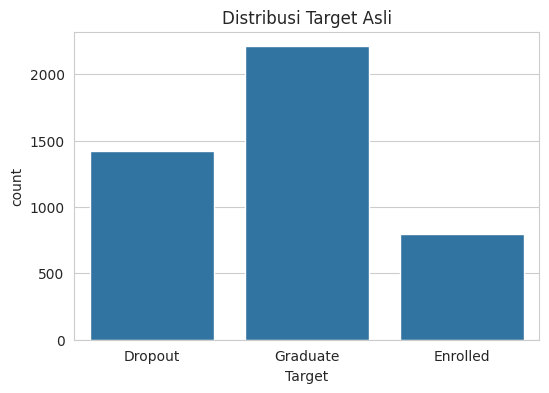

In [46]:
print(df['Target'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)
plt.title('Distribusi Target Asli')
plt.show()

In [47]:
df['dropout_risk'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
print(df['dropout_risk'].value_counts())

dropout_risk
0    3003
1    1421
Name: count, dtype: int64


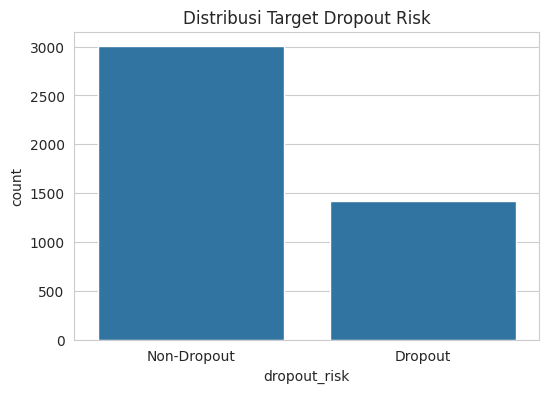

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='dropout_risk', data=df)
plt.title('Distribusi Target Dropout Risk')
plt.xticks([0,1], ['Non-Dropout', 'Dropout'])
plt.show()

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [50]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

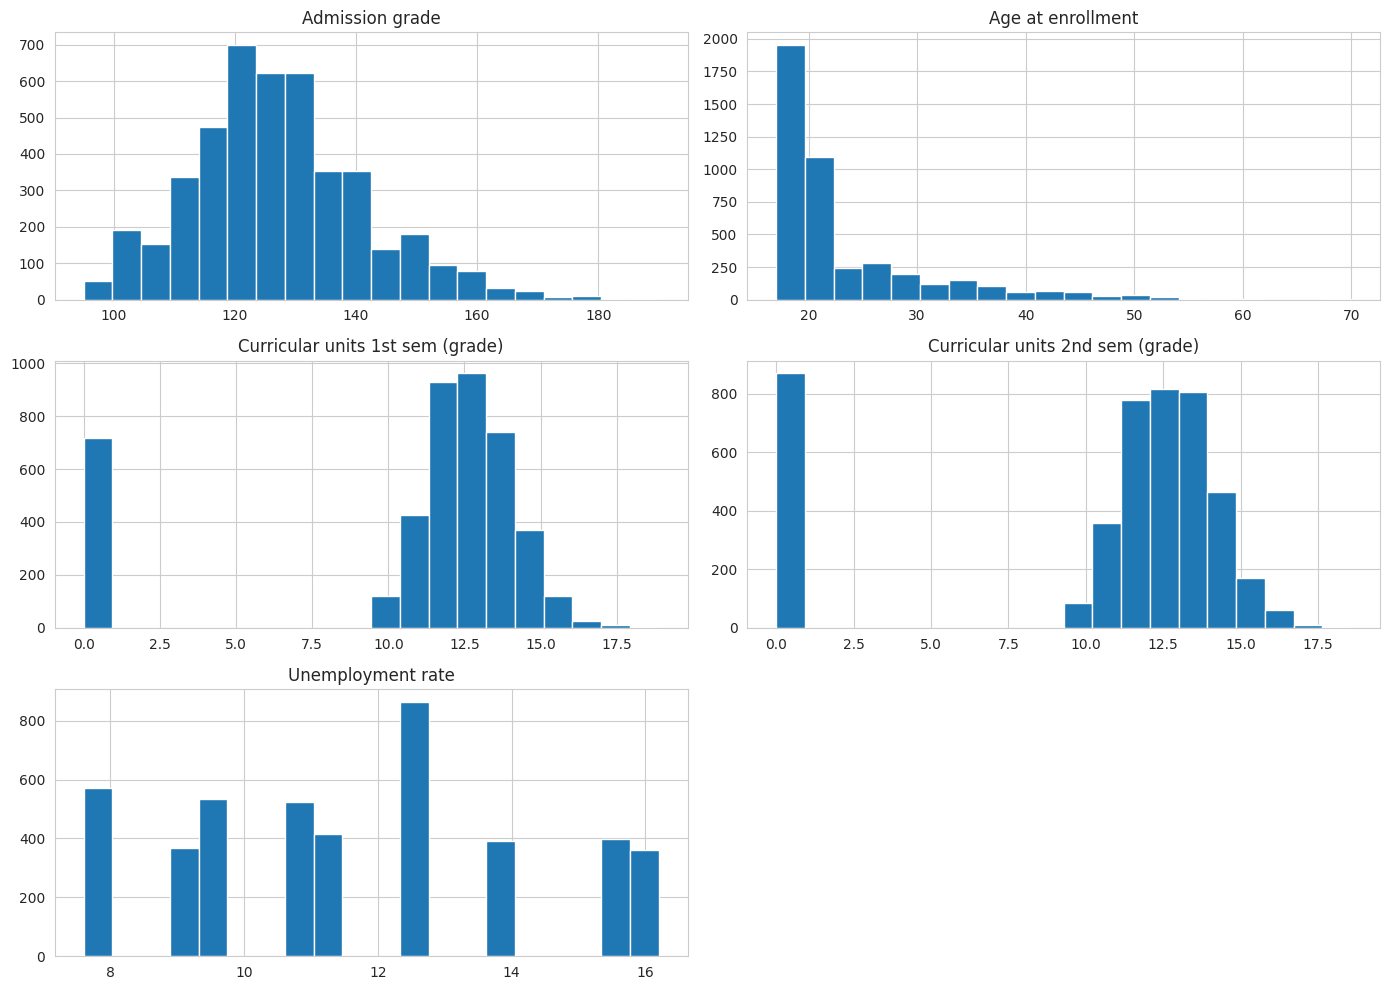

In [51]:
selected_cols = [
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate'
]

df[selected_cols].hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

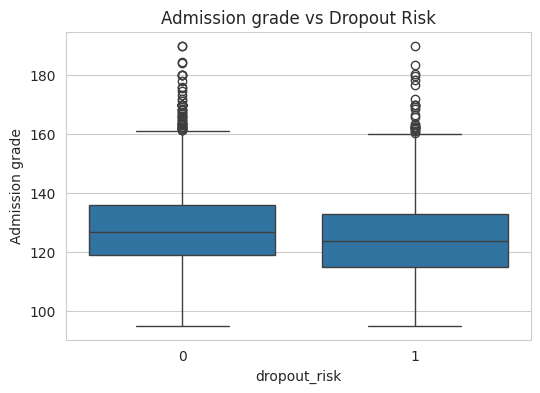

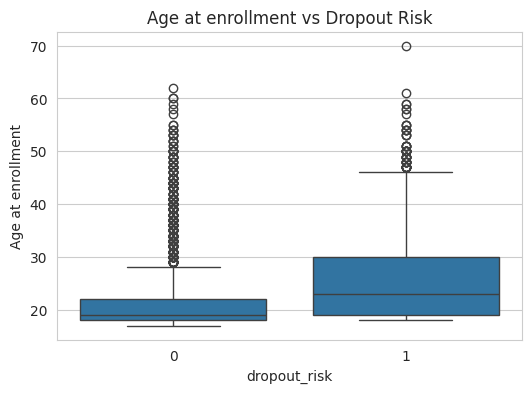

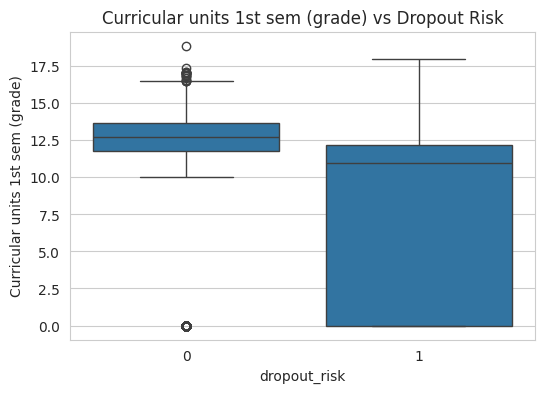

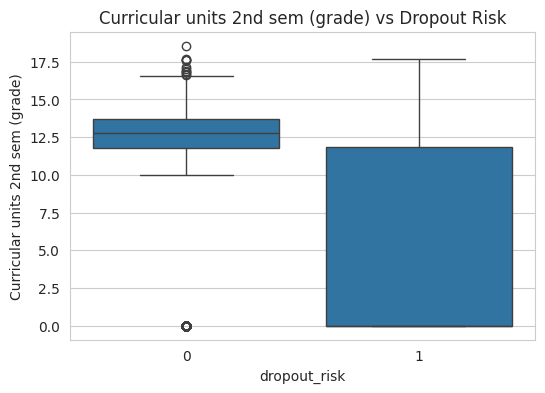

In [52]:
important_cols = [
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for col in important_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='dropout_risk', y=col, data=df)
    plt.title(f'{col} vs Dropout Risk')
    plt.show()

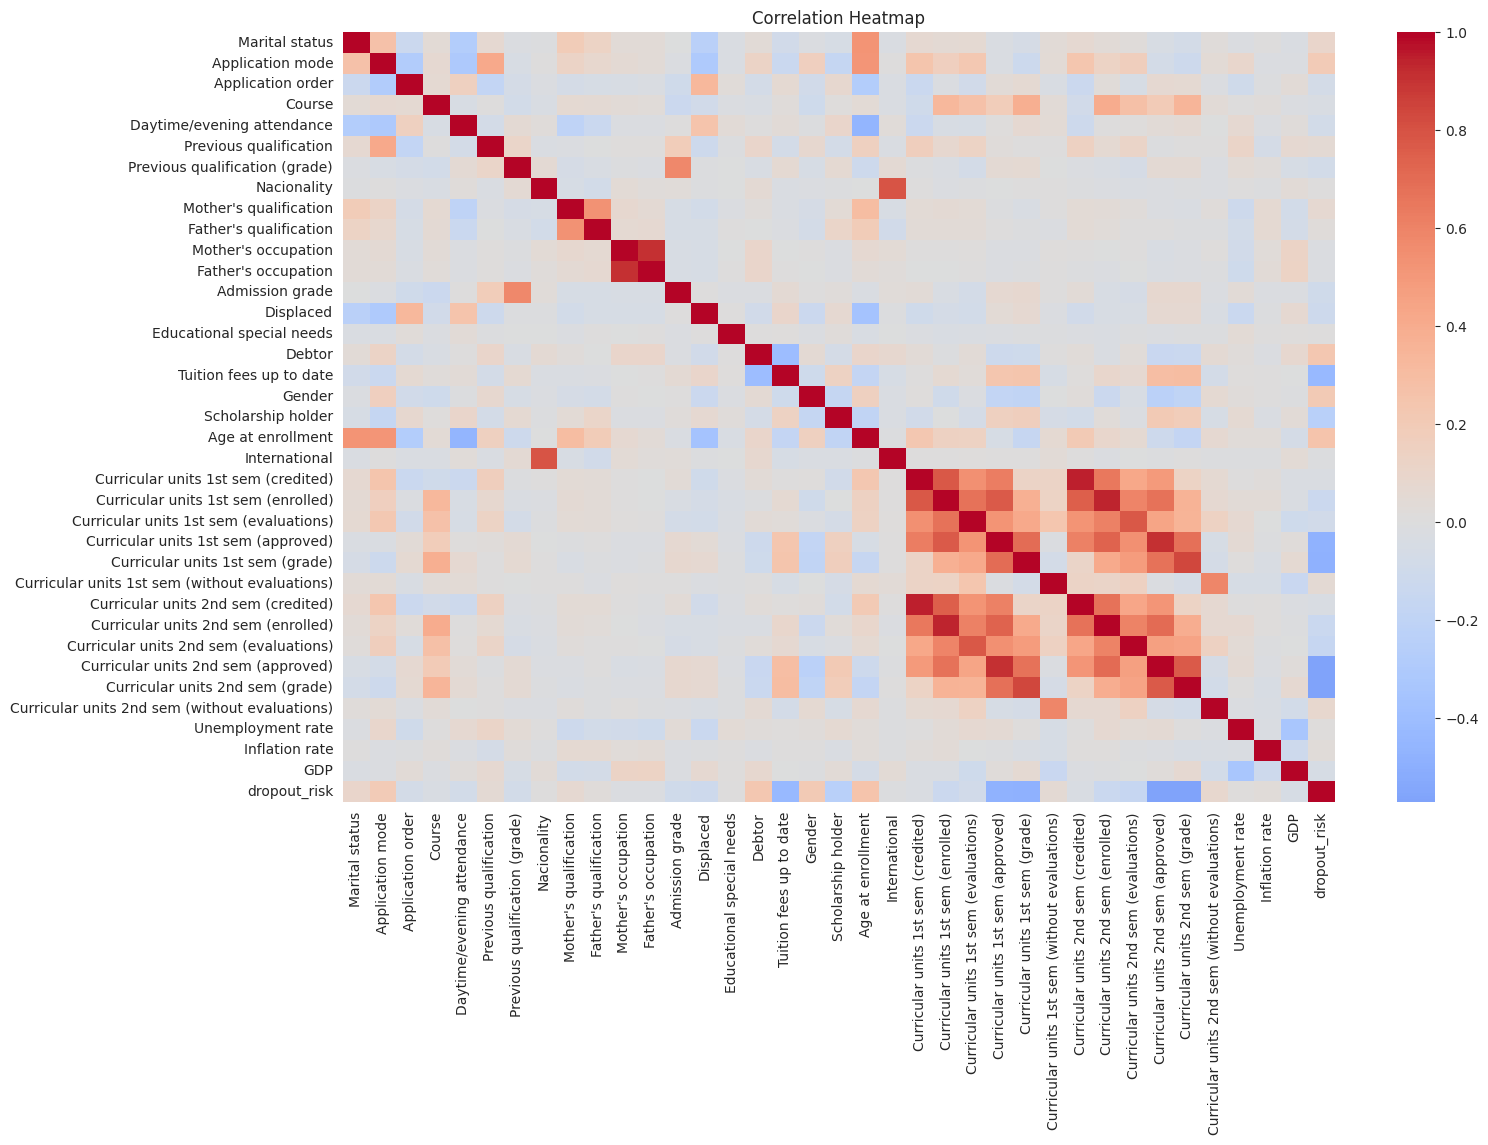

In [53]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(16,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [54]:
target_corr = corr['dropout_risk'].sort_values(ascending=False)
print(target_corr)

dropout_risk                                      1.000000
Age at enrollment                                 0.254215
Debtor                                            0.229407
Gender                                            0.203983
Application mode                                  0.198458
Marital status                                    0.093712
Curricular units 2nd sem (without evaluations)    0.079901
Mother's qualification                            0.064958
Curricular units 1st sem (without evaluations)    0.054230
Previous qualification                            0.049379
Inflation rate                                    0.027826
Father's qualification                            0.018295
Unemployment rate                                 0.012980
Nacionality                                       0.008346
Educational special needs                         0.002806
International                                    -0.010360
Mother's occupation                              -0.0219

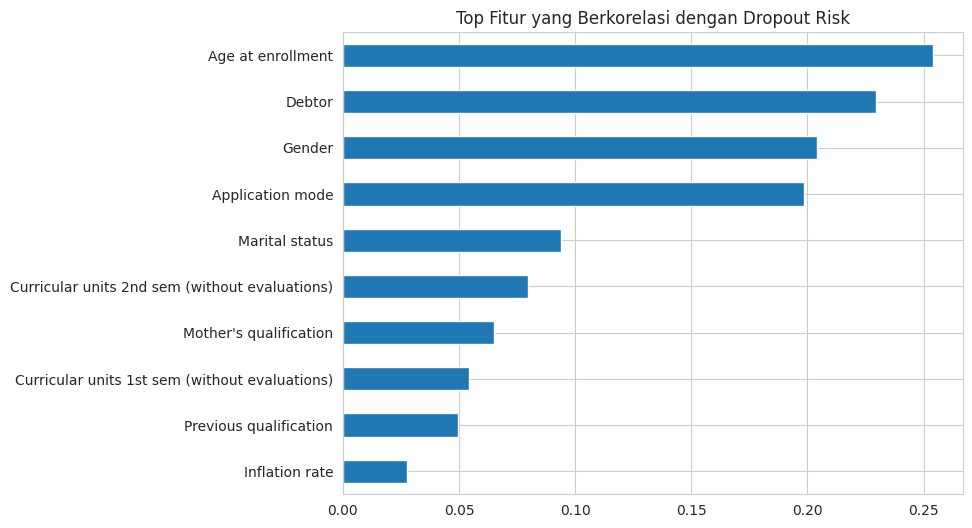

In [55]:
target_corr.drop('dropout_risk').sort_values().tail(10).plot(kind='barh', figsize=(8,6))
plt.title('Top Fitur yang Berkorelasi dengan Dropout Risk')
plt.show()

In [56]:
## Insight Awal EDA
# 1. Dataset tidak memiliki missing value dan duplikat.
# 2. Distribusi target menunjukkan adanya kelas dropout dan non-dropout yang perlu dicek keseimbangannya.
# 3. Nilai semester 1 dan semester 2 tampak memiliki hubungan kuat dengan status dropout.
# 4. Faktor administrasi seperti `Tuition fees up to date` dan `Debtor` diduga berpengaruh terhadap risiko dropout.
# 5. Fitur akademik akan menjadi kandidat penting pada tahap modeling.

In [57]:
target_counts = df['dropout_risk'].value_counts()
target_percent = df['dropout_risk'].value_counts(normalize=True) * 100

print("Jumlah kelas:")
print(target_counts)
print("\nPersentase kelas:")
print(target_percent.round(2))

Jumlah kelas:
dropout_risk
0    3003
1    1421
Name: count, dtype: int64

Persentase kelas:
dropout_risk
0    67.88
1    32.12
Name: proportion, dtype: float64


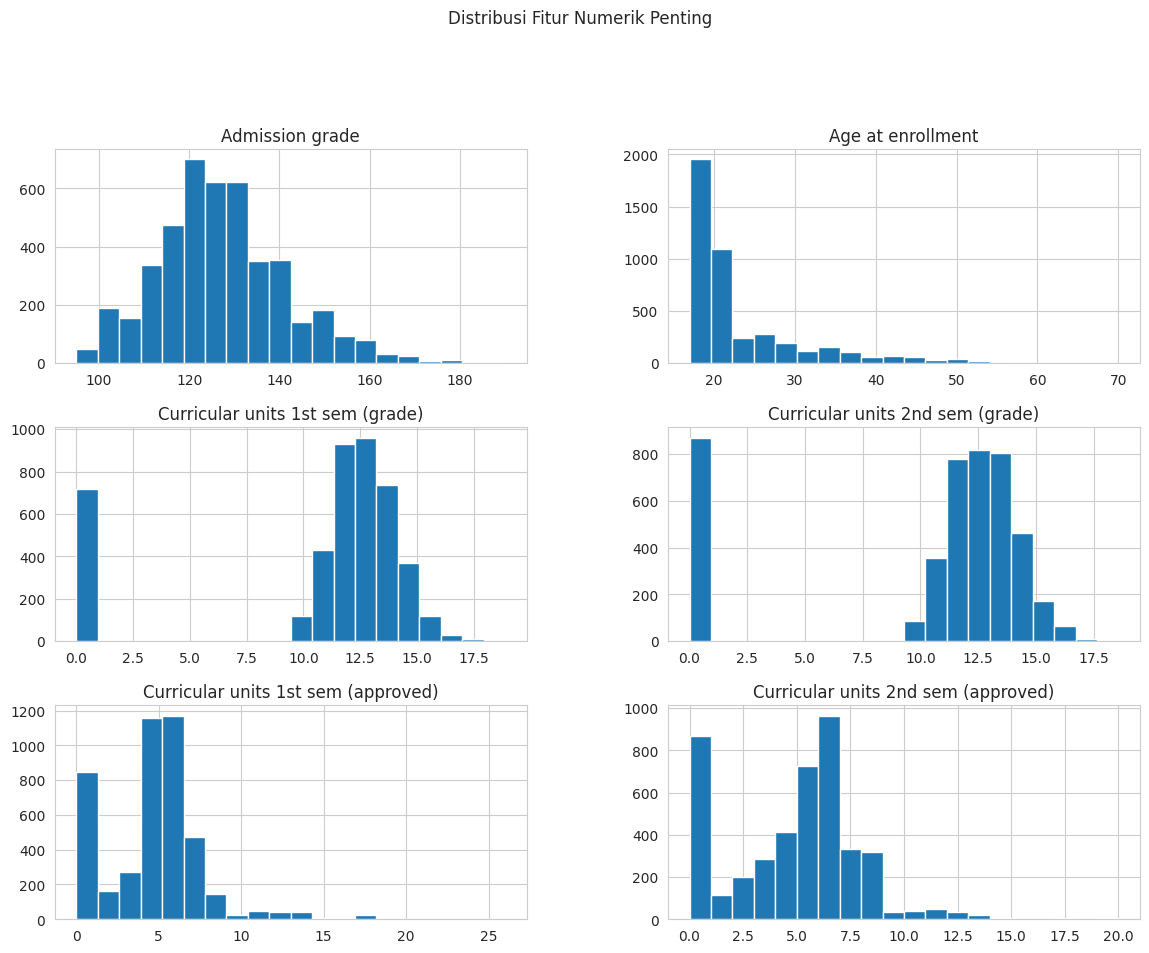

In [58]:
num_cols = [
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)'
]

df[num_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Distribusi Fitur Numerik Penting", y=1.02)
plt.show()

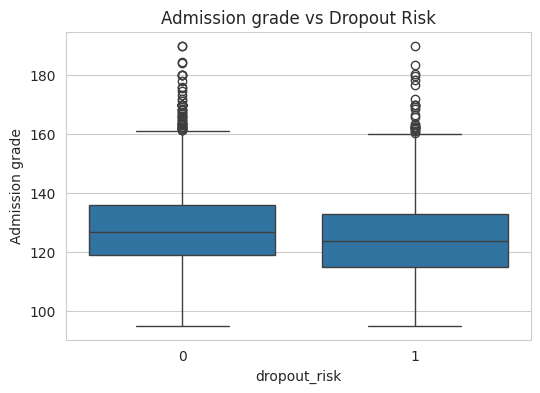

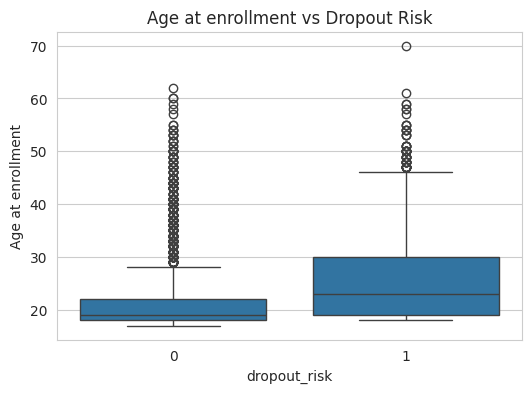

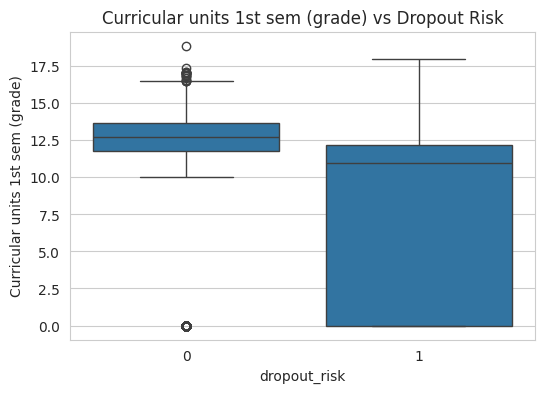

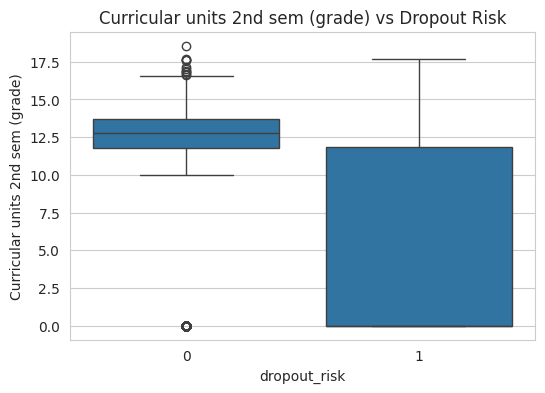

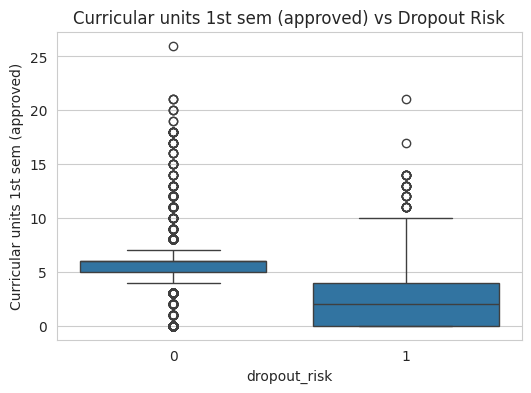

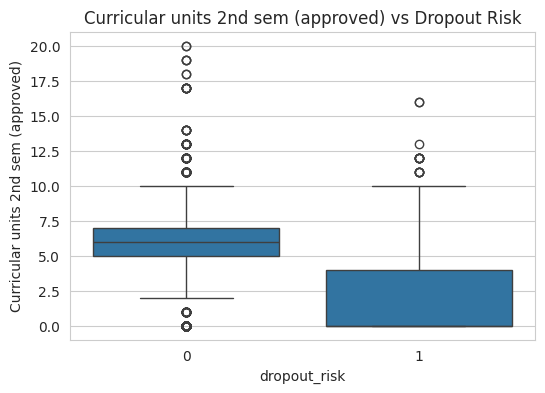

In [59]:
important_cols = [
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)'
]

for col in important_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='dropout_risk', y=col, data=df)
    plt.title(f'{col} vs Dropout Risk')
    plt.show()

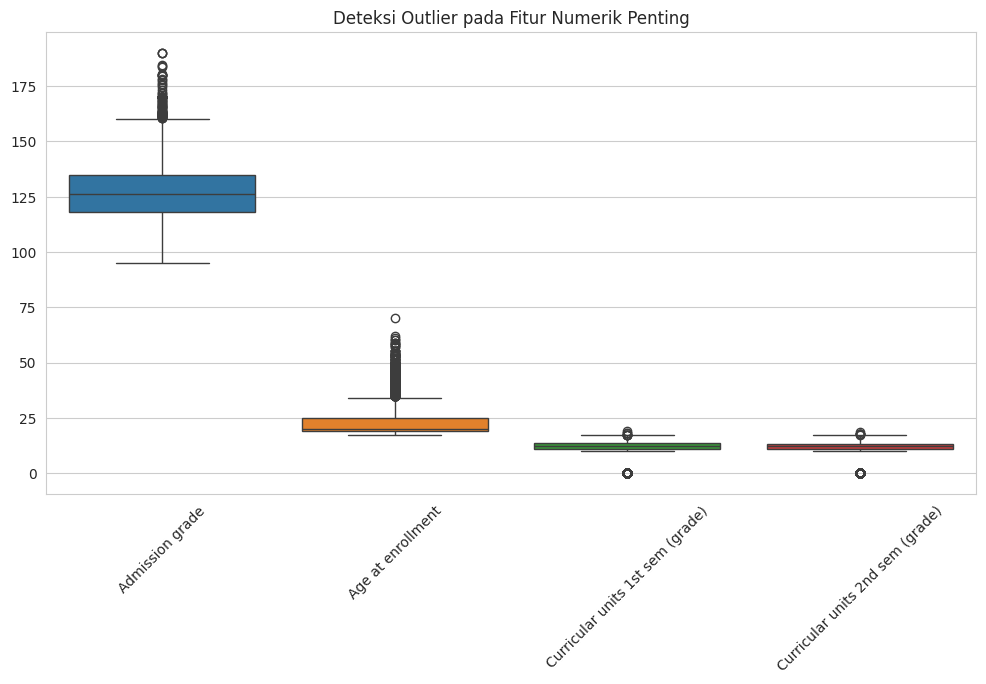

In [60]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Admission grade', 'Age at enrollment',
                     'Curricular units 1st sem (grade)',
                     'Curricular units 2nd sem (grade)']])
plt.xticks(rotation=45)
plt.title("Deteksi Outlier pada Fitur Numerik Penting")
plt.show()

In [61]:
import os
from sklearn.model_selection import train_test_split

os.makedirs('/kaggle/working/data/processed', exist_ok=True)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['dropout_risk']
)

train_df.to_csv('/kaggle/working/data/processed/train.csv', index=False)
test_df.to_csv('/kaggle/working/data/processed/test.csv', index=False)
df.to_csv('/kaggle/working/data/processed/processed_data.csv', index=False)

print("File berhasil disimpan:")
print("- /kaggle/working/data/processed/train.csv")
print("- /kaggle/working/data/processed/test.csv")
print("- /kaggle/working/data/processed/processed_data.csv")

File berhasil disimpan:
- /kaggle/working/data/processed/train.csv
- /kaggle/working/data/processed/test.csv
- /kaggle/working/data/processed/processed_data.csv
